<a href="https://colab.research.google.com/github/Aziz-25-TR/Automotive-Sales-Analysis/blob/main/sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url_data = "https://docs.google.com/spreadsheets/d/1GuFkH44urw4ACqt5gsWhi1Scei0pGS2L/export?format=csv"
df = pd.read_csv(url_data)

print("Data berhasil di-load!")
print("Jumlah baris dan kolom:", df.shape)
df.head()


Data berhasil di-load!
Jumlah baris dan kolom: (10000, 16)


,sales_date,order_id,customer_name,branch,product_name,category,color,price,quantity,payment_type,trade_in,discount,total,total_sales,status,branch_address
0,2025-12-13,TRX00001,Customer_913,Jakarta,Daihatsu Xenia 1.5 R CVT,MPV,Silver Metalik,240000000,1,Cash + Trade In,74000000,0,240000000,166000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
1,2025-10-15,TRX00002,Customer_261,Jakarta,Toyota Rush 1.5 S GR Sport CVT,SUV,Hitam Metalik,300000000,1,Kredit,0,0,300000000,300000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
2,2025-01-04,TRX00003,Customer_4465,Kendari,Honda BR-V 1.5 E CVT,MPV,Merah,310000000,1,Kredit + Trade In,111000000,0,310000000,199000000,completed,"Jl. Ahmad Yani No. 33, Kendari"
3,2025-02-17,TRX00004,Customer_2788,Padang,Honda Brio Satya E CVT,Hatchback,Merah,190000000,1,Kredit,0,0,190000000,190000000,completed,"Jl. Khatib Sulaiman No. 10, Padang"
4,2025-10-02,TRX00005,Customer_2941,Karawang,Isuzu D-Max Double Cabin 4x4 AT,Pickup,Hitam Metalik,520000000,1,Cash + Trade In,93000000,0,520000000,427000000,refund,"Jl. Ahmad Yani No. 5, Karawang"


In [2]:
# 1. Tampilkan jumlah baris dan jumlah kolom dari df
print("Jumlah baris dan kolom:", df.shape)

# 2. Tampilkan nama-nama semua kolom
print("Nama-nama kolom:")
print(df.columns)

# 3. Tampilkan 10 baris pertama dari data
df.head(10)

Jumlah baris dan kolom: (10000, 16)
Nama-nama kolom:
Index(['sales_date', 'order_id', 'customer_name', 'branch', 'product_name',
       'category', 'color', 'price', 'quantity', 'payment_type', 'trade_in',
       'discount', 'total', 'total_sales', 'status', 'branch_address'],
      dtype='object')


,sales_date,order_id,customer_name,branch,product_name,category,color,price,quantity,payment_type,trade_in,discount,total,total_sales,status,branch_address
0,2025-12-13,TRX00001,Customer_913,Jakarta,Daihatsu Xenia 1.5 R CVT,MPV,Silver Metalik,240000000,1,Cash + Trade In,74000000,0,240000000,166000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
1,2025-10-15,TRX00002,Customer_261,Jakarta,Toyota Rush 1.5 S GR Sport CVT,SUV,Hitam Metalik,300000000,1,Kredit,0,0,300000000,300000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
2,2025-01-04,TRX00003,Customer_4465,Kendari,Honda BR-V 1.5 E CVT,MPV,Merah,310000000,1,Kredit + Trade In,111000000,0,310000000,199000000,completed,"Jl. Ahmad Yani No. 33, Kendari"
3,2025-02-17,TRX00004,Customer_2788,Padang,Honda Brio Satya E CVT,Hatchback,Merah,190000000,1,Kredit,0,0,190000000,190000000,completed,"Jl. Khatib Sulaiman No. 10, Padang"
4,2025-10-02,TRX00005,Customer_2941,Karawang,Isuzu D-Max Double Cabin 4x4 AT,Pickup,Hitam Metalik,520000000,1,Cash + Trade In,93000000,0,520000000,427000000,refund,"Jl. Ahmad Yani No. 5, Karawang"
5,2025-07-05,TRX00006,Customer_3101,Bandung,Wuling Air ev Long Range,City Car (EV),Abu-abu,250000000,1,Kredit,0,0,250000000,250000000,completed,"Jl. Soekarno Hatta No. 88, Bandung"
6,2025-02-21,TRX00007,Customer_570,Jakarta,Honda BR-V 1.5 E CVT,MPV,Hitam Metalik,310000000,2,Kredit + Trade In,224000000,0,620000000,396000000,completed,"Jl. MT. Haryono No. 12, Jakarta"
7,2025-12-16,TRX00008,Customer_2989,Pontianak,Mitsubishi Pajero Sport Dakar 4x2 AT,SUV,Putih Pearl,580000000,1,Kredit,0,0,580000000,580000000,completed,"Jl. Ahmad Yani No. 45, Pontianak"
8,2025-11-24,TRX00009,Customer_1402,Semarang,Honda BR-V 1.5 E CVT,MPV,Silver Metalik,310000000,1,Kredit,0,0,310000000,310000000,completed,"Jl. Setiabudi No. 60, Semarang"
9,2025-07-25,TRX00010,Customer_1800,Karawang,Toyota Innova Zenix 2.0 V CVT,MPV,Hitam Metalik,450000000,1,Kredit + Trade In,167000000,0,450000000,283000000,completed,"Jl. Ahmad Yani No. 5, Karawang"


category
SUV              4565
MPV              3915
Hatchback         519
Pickup            516
City Car (EV)     485
dtype: int64


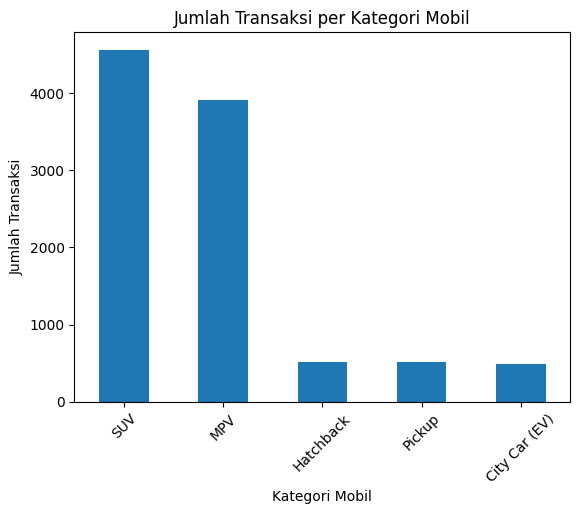

In [3]:
# Hitung jumlah transaksi per kategori mobil (category), urutkan dari yang paling banyak
jumlah_transaksi = (
    df.groupby("category")
      .size()
      .sort_values(ascending=False)
)
print(jumlah_transaksi)


# (opsional) buat bar chart dari hasilnya
jumlah_transaksi.plot(kind="bar")

plt.title("Jumlah Transaksi per Kategori Mobil")
plt.xlabel("Kategori Mobil")
plt.ylabel("Jumlah Transaksi")
plt.xticks(rotation=45)
plt.show()


In [4]:

# Hitung jumlah transaksi per cabang (branch), urutkan dari yang paling banyak
jumlah_transaksi_cabang = df["branch"].value_counts()


# Tampilkan cabang dengan jumlah transaksi terbanyak
print("Cabang dengan transaksi terbanyak:")
print(jumlah_transaksi_cabang.head(1))

Cabang dengan transaksi terbanyak:
branch
Jakarta    1058
Name: count, dtype: int64


In [5]:
# 1. Cek missing value, lalu isi trade_in yang kosong dengan 0
print("Missing value sebelum cleaning:")
print(df.isnull().sum())

df["trade_in"] = df["trade_in"].fillna(0)


# 2. Cek dan hapus baris duplikat
print("\nJumlah duplikat penuh:", df.duplicated().sum())
print("Jumlah duplikat order_id:", df["order_id"].duplicated().sum())

# Hapus duplikat penuh terlebih dahulu
df = df.drop_duplicates()

# Hapus duplikat berdasarkan order_id
df = df.drop_duplicates(subset="order_id")


# 3. Standarisasi kolom payment_type
df["payment_type"] = df["payment_type"].str.strip().str.title()


# 4. Ubah kolom sales_date jadi tipe data datetime
df["sales_date"] = pd.to_datetime(df["sales_date"])


# 5. Tampilkan df.info()
df.info()

Missing value sebelum cleaning:
sales_date        0
order_id          0
customer_name     0
branch            0
product_name      0
category          0
color             0
price             0
quantity          0
payment_type      0
trade_in          0
discount          0
total             0
total_sales       0
status            0
branch_address    0
dtype: int64

Jumlah duplikat penuh: 0
Jumlah duplikat order_id: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sales_date      10000 non-null  datetime64[ns]
 1   order_id        10000 non-null  object        
 2   customer_name   10000 non-null  object        
 3   branch          10000 non-null  object        
 4   product_name    10000 non-null  object        
 5   category        10000 non-null  object        
 6   color           10000 non-null  object        
 7   

branch     category
Palembang  SUV         157626000000
Jakarta    SUV         155749000000
Malang     SUV         154891000000
Batam      SUV         151981000000
Karawang   SUV         150498000000
Name: total_sales, dtype: int64


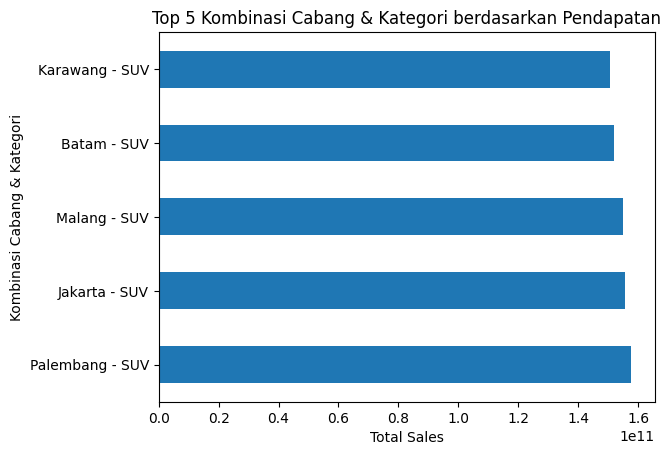

In [6]:
# 1. Filter transaksi yang statusnya "completed"
completed_df = df[df["status"] == "completed"]


# 2. Groupby kombinasi branch dan category, jumlahkan total_sales
pendapatan_cabang_kategori = (
    completed_df
    .groupby(["branch", "category"])["total_sales"]
    .sum()
)


# 3. Urutkan dari terbesar, ambil 5 kombinasi teratas
top_5 = pendapatan_cabang_kategori.sort_values(
    ascending=False
).head(5)

print(top_5)


# 4. Buat bar chart horizontal dari 5 kombinasi teratas
top_5_df = top_5.reset_index()

top_5_df["kombinasi"] = (
    top_5_df["branch"] + " - " + top_5_df["category"]
)

top_5_df.plot(
    kind="barh",
    x="kombinasi",
    y="total_sales",
    legend=False
)

plt.title("Top 5 Kombinasi Cabang & Kategori berdasarkan Pendapatan")
plt.xlabel("Total Sales")
plt.ylabel("Kombinasi Cabang & Kategori")
plt.show()